In [ ]:
#1.Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#2.Load Dataset

In [3]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.mnist.load_data()

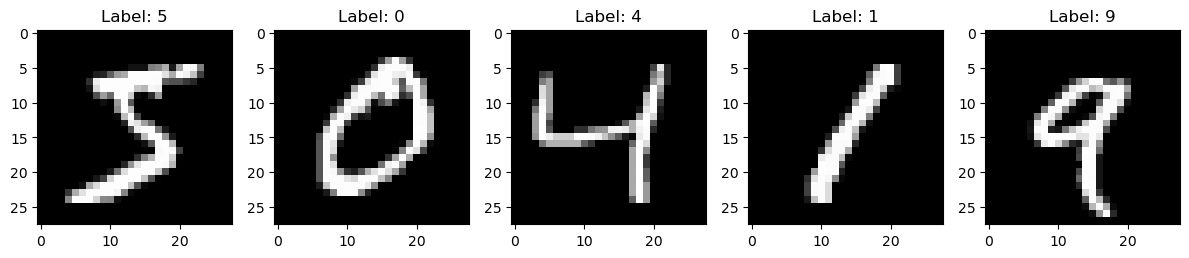

In [4]:
plt.figure(figsize=(12,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(f"Label: {y_train_full[i]}")
    plt.axis("on")

plt.tight_layout()
plt.show()


In [5]:
#3.Explore the dataset

In [6]:
print(X_train_full.shape)
print(y_train_full.shape)

print(X_test_full.shape)
print(y_test_full.shape)

print(X_train_full.dtype)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
uint8


In [7]:
#4.Preprocess the data

In [8]:
X_train = X_train_full.reshape(60000,784)
X_test = X_test_full.reshape(10000,784)

In [9]:
#Normalize

In [10]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

In [11]:
#OneHot encoded Labels

In [12]:
y_train = keras.utils.to_categorical(y_train_full,10)
y_test = keras.utils.to_categorical(y_test_full,10)


In [38]:
#Build the neural network

In [14]:
model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [15]:
#6.Compile the model

In [16]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
#7. Train the model

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test,y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8602 - loss: 0.5122 - val_accuracy: 0.9179 - val_loss: 0.2862
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9255 - loss: 0.2661 - val_accuracy: 0.9337 - val_loss: 0.2349
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9364 - loss: 0.2233 - val_accuracy: 0.9437 - val_loss: 0.2050
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9447 - loss: 0.1936 - val_accuracy: 0.9478 - val_loss: 0.1867
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9516 - loss: 0.1719 - val_accuracy: 0.9511 - val_loss: 0.1710
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9554 - loss: 0.1562 - val_accuracy: 0.9548 - val_loss: 0.1593
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9592 - loss: 0.1432 - val_accuracy: 0.9551 - val_loss: 0.1495
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9617 - loss: 0.1334 - val_accuracy: 0.

In [19]:
#8.Plot Learning Curves

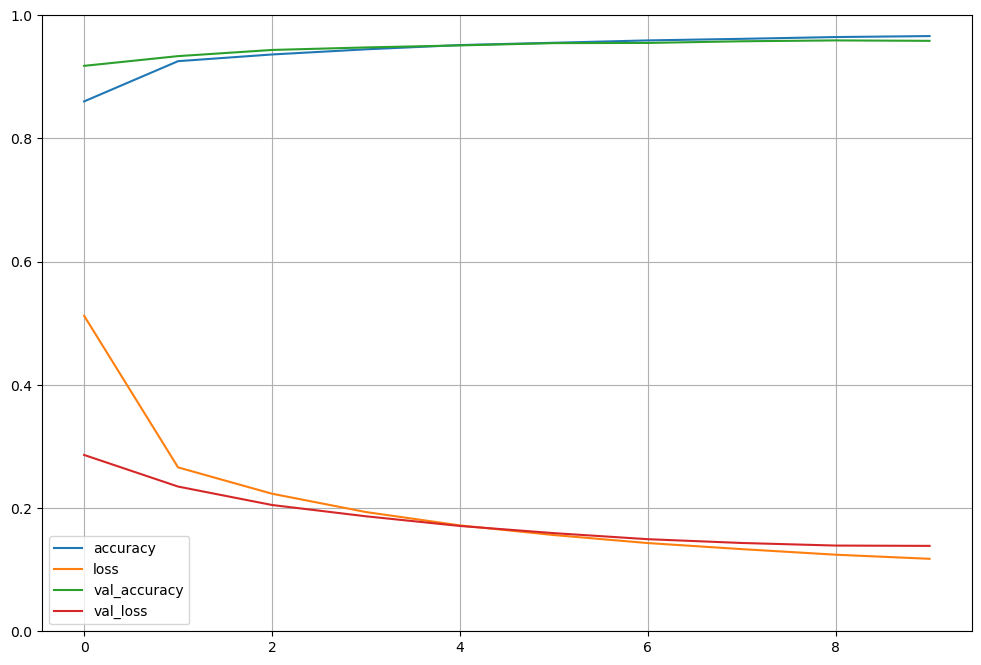

In [20]:
history_df = pd.DataFrame(history.history)

history_df.plot(figsize=(12,8), grid=True)

plt.gca().set_ylim(0,1)

plt.show()

In [21]:
#9.Evaluate the model

In [22]:
loss, accuracy = model.evaluate(X_test,y_test)

print(loss)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9585 - loss: 0.1386
0.13864177465438843
0.9585000276565552


In [23]:
#10. Make predictions

In [27]:
#Convert probabilities
y_pred_probs = model.predict(X_test)

#Covert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

#Convert one-hot encoded true labels to class labels
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [28]:
#11. Classification Report

In [29]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.99      0.97      0.98      1135
           2       0.96      0.96      0.96      1032
           3       0.93      0.97      0.95      1010
           4       0.95      0.96      0.96       982
           5       0.96      0.94      0.95       892
           6       0.97      0.96      0.96       958
           7       0.96      0.95      0.96      1028
           8       0.95      0.94      0.94       974
           9       0.94      0.95      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [30]:
#Confusion matrix

In [31]:
cm = confusion_matrix(y_true,y_pred)

print(cm)

[[ 959    0    2    2    0    5    5    2    1    4]
 [   0 1103    8    2    1    1    2    3   15    0]
 [   3    0  993   11    5    0    5    6    7    2]
 [   3    0    9  976    1    3    0    8    7    3]
 [   1    0    2    1  944    0    5    3    2   24]
 [   4    1    0   23    5  839    8    0    7    5]
 [   9    2    3    2    9   10  920    0    3    0]
 [   0    2   17    6    4    1    0  981    1   16]
 [   4    0    5   11    8   10    7    7  913    9]
 [   5    4    0   10   14    4    1    7    7  957]]


In [32]:
#13. Display the Incorrect predictions

In [33]:
incorrect_indices = np.where(y_pred != y_true)[0]

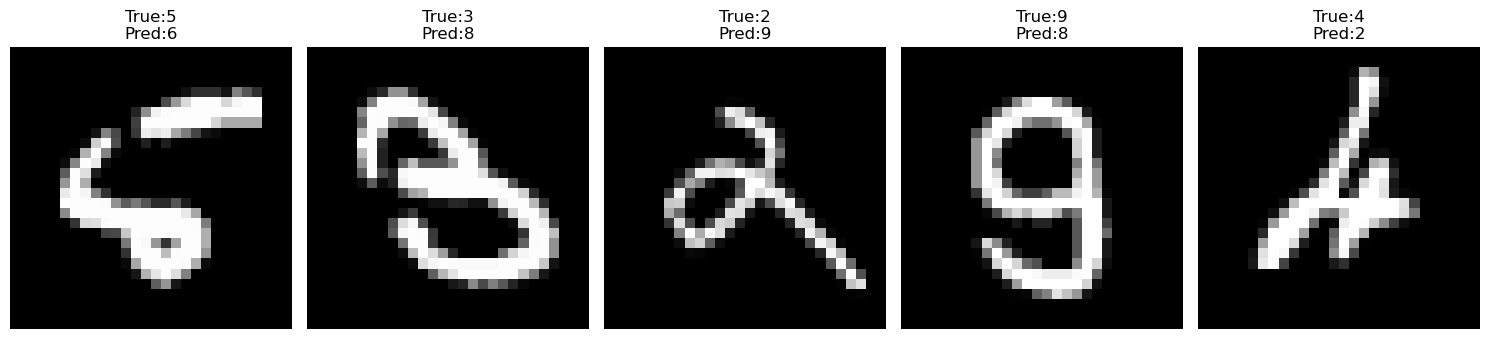

In [34]:
plt.figure(figsize=(15,5))

for i, idx in enumerate(incorrect_indices[:5]):

    plt.subplot(1,5,i+1)

    plt.imshow(X_test_full[idx], cmap="gray")

    plt.title(f"True:{y_true[idx]}\nPred:{y_pred[idx]}")

    plt.axis("off")

plt.tight_layout()

plt.show()